In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import multivariate_normal
from scipy.spatial import distance
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [ ]:
np.random.seed(1)
sigma1 = np.array([[1.1, 0.3],
          [0.3, 1.9]])
sigma2 = sigma1
mu1 = np.array([0, 0])
mu2 = np.array([3, 3])
C1 = np.random.multivariate_normal(mu1, sigma1, 1000)
C2 = np.random.multivariate_normal(mu2, sigma2, 1000)

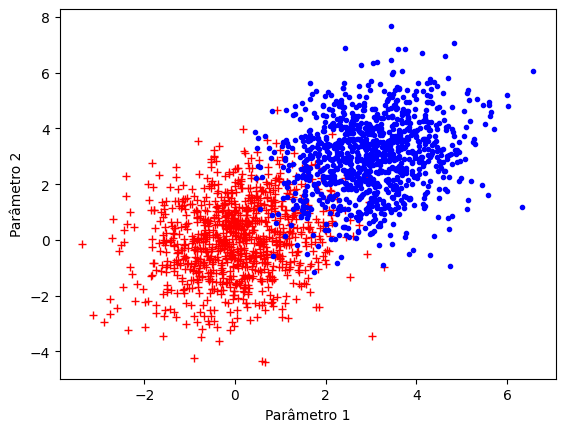

In [ ]:
plt.plot(C1[:,0], C1[:,1], 'r+')
plt.plot(C2[:,0], C2[:,1], 'b.')
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.show()

Implementando o classificador de bayes

In [ ]:
x=np.array([1, 2.2])
dpp1=multivariate_normal.pdf(x, mu1, sigma1)
dpp2=multivariate_normal.pdf(x, mu2, sigma2)
if dpp1>dpp2:
    print("Classe 1")
else:
    print("Classe 2")

Classe 1


Plotando a superfície de separação a partir dos dados

In [ ]:
events = np.random.uniform(-1, 4, size=(10000, 2))
aux=np.zeros(10000)
for i in range(10000):
  aux[i]=multivariate_normal.pdf(events[i,:], mu1, sigma1)-multivariate_normal.pdf(events[i,:], mu2, sigma2)

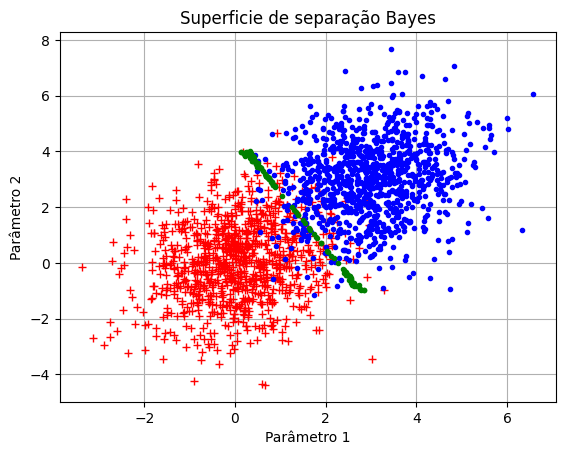

In [ ]:
superficie=events[(aux < 0.0005) & (aux > -0.0005),:]
plt.plot(C1[:,0], C1[:,1], 'r+')
plt.plot(C2[:,0], C2[:,1], 'b.')
plt.plot(superficie[:,0], superficie[:,1], 'g.')
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.title("Superficie de separação Bayes")
plt.grid()
plt.show()

Clasificador pela distância euclidiana das médias

In [ ]:

x = np.array([1, 2.2])
distance_to_mu1 = np.linalg.norm(x - mu1)
distance_to_mu2 = np.linalg.norm(x - mu2)

if distance_to_mu1 < distance_to_mu2:
    print("Classe 1")
else:
    print("Classe 2")


Classe 2


In [ ]:
events = np.random.uniform(-1, 4, size=(10000, 2))
aux=np.zeros(10000)
for i in range(10000):
  aux[i]=np.linalg.norm(events[i,:] - mu1)-np.linalg.norm(events[i,:] - mu2)

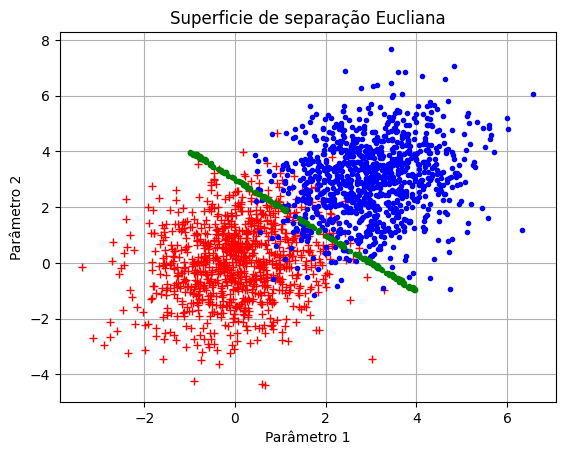

In [ ]:
superficie=events[(aux < 0.05) & (aux > -0.05),:]
plt.plot(C1[:,0], C1[:,1], 'r+')
plt.plot(C2[:,0], C2[:,1], 'b.')
plt.plot(superficie[:,0], superficie[:,1], 'g.')
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.title("Superficie de separação Eucliana")
plt.grid()
plt.show()

In [ ]:

# Classificando o vetor x
x = np.array([1, 2.2])
distancem_to_mu1 = distance.mahalanobis(x, mu1, np.linalg.inv(sigma1))
distancem_to_mu2 = distance.mahalanobis(x, mu2, np.linalg.inv(sigma2))

if distancem_to_mu1 < distancem_to_mu2:
    print("Classe 1")
else:
    print("Classe 2")


Classe 1


In [ ]:
events = np.random.uniform(-1, 4, size=(10000, 2))
aux=np.zeros(10000)
for i in range(10000):
  aux[i]=distance.mahalanobis(events[i,:], mu1, np.linalg.inv(sigma1))-distance.mahalanobis(events[i,:], mu2, np.linalg.inv(sigma2))

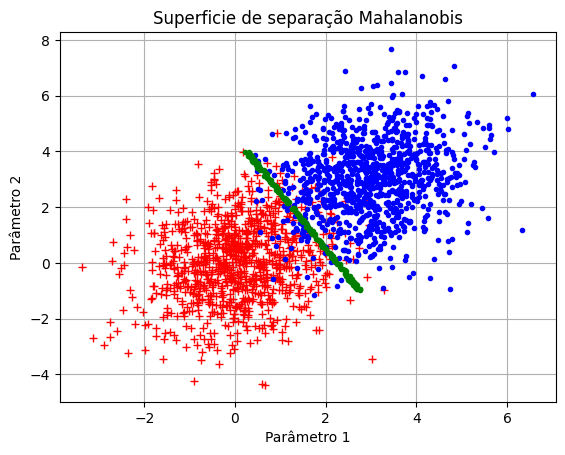

In [ ]:
superficie=events[(aux < 0.05) & (aux > -0.05),:]
plt.plot(C1[:,0], C1[:,1], 'r+')
plt.plot(C2[:,0], C2[:,1], 'b.')
plt.plot(superficie[:,0], superficie[:,1], 'g.')
plt.xlabel("Parâmetro 1")
plt.ylabel("Parâmetro 2")
plt.title("Superficie de separação Mahalanobis")
plt.grid()
plt.show()

In [ ]:
alvoC1=np.ones(1000)
alvoC2=np.zeros(1000)
X=np.concatenate((C1, C2), axis=0)
y=np.concatenate((alvoC1, alvoC2), axis=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

Bayes ingênio

In [ ]:
from sklearn.metrics import accuracy_score
gnb = GaussianNB()
gnb.fit(X_train, y_train)
if gnb.predict([[1, 2]])==1:
    print("Classe 1")
else:
    print("Classe 2")
y_pred = gnb.predict(X_test)
accuracy_score(y_test, y_pred)

Classe 1


0.87

Vizinho mais próximo

In [ ]:
neigh = KNeighborsClassifier(n_neighbors=5)
neigh.fit(X_train, y_train)
if neigh.predict([[1, 2]])==1:
    print("Classe 1")
else:
    print("Classe 2")
y_pred = neigh.predict(X_test)
accuracy_score(y_test, y_pred)
#from sklearn.metrics import confusion_matrix
#confusion_matrix(y_test, y_pred)

Classe 1


0.8916666666666667